In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer.csv")
df.head()

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0


In [29]:
df.isnull().sum()

Age                       0
AnnualIncome              0
NumberOfPurchases         0
TimeSpentOnWebsite        0
CustomerTenureYears       0
LastPurchaseDaysAgo       0
Gender                    0
ProductCategory           0
PreferredDevice           0
Region                    0
ReferralSource            0
CustomerSegment           0
LoyaltyProgram            0
DiscountsAvailed          0
SessionCount              0
CustomerSatisfaction      0
PurchaseStatus            0
SpendingScore           540
dtype: int64

In [30]:
import math
median_SpendingScore = math.floor(df.SpendingScore.median())
median_SpendingScore

47

In [31]:
df.SpendingScore = df.SpendingScore.fillna(median_SpendingScore)
df

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Male,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0
499996,40,59758.01615,13,7.124139,-0.006796,123,Male,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0
499997,50,64968.69666,10,28.440505,0.649710,20,Male,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0
499998,38,150832.32070,8,50.161579,2.903859,8,Female,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0


In [32]:
dummies = pd.get_dummies(df['Gender'], dtype=int)
dummies

,Female,Male
0,0,1
1,1,0
2,0,1
3,0,1
4,0,1
...,...,...
499995,0,1
499996,0,1
499997,0,1
499998,1,0


In [33]:
merged = pd.concat([df,dummies],axis='columns')
merged

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore,Female,Male
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0,0,1
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0,1,0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0,0,1
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0,0,1
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Male,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0,0,1
499996,40,59758.01615,13,7.124139,-0.006796,123,Male,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0,0,1
499997,50,64968.69666,10,28.440505,0.649710,20,Male,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0,0,1
499998,38,150832.32070,8,50.161579,2.903859,8,Female,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0,1,0


In [34]:
df = merged.drop(['Gender','Female'],axis='columns')
df

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore,Male
0,37,57722.57241,19,5.908826,1.093430,11,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0,1
1,63,21328.92588,10,6.970749,0.649246,20,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0,0
2,60,150537.74250,19,35.004954,3.858211,25,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0,1
3,19,63508.76255,10,14.818000,7.554374,20,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0,1
4,54,100399.55840,19,55.925462,0.197411,92,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0,1
499996,40,59758.01615,13,7.124139,-0.006796,123,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0,1
499997,50,64968.69666,10,28.440505,0.649710,20,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0,1
499998,38,150832.32070,8,50.161579,2.903859,8,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0,0


In [35]:
df.isnull().sum()

Age                     0
AnnualIncome            0
NumberOfPurchases       0
TimeSpentOnWebsite      0
CustomerTenureYears     0
LastPurchaseDaysAgo     0
ProductCategory         0
PreferredDevice         0
Region                  0
ReferralSource          0
CustomerSegment         0
LoyaltyProgram          0
DiscountsAvailed        0
SessionCount            0
CustomerSatisfaction    0
PurchaseStatus          0
SpendingScore           0
Male                    0
dtype: int64

In [37]:
features = [
    'Age',
    'AnnualIncome',
    'NumberOfPurchases',
    'TimeSpentOnWebsite',
    'LastPurchaseDaysAgo',
    'Male',
    'SpendingScore'
]

X = df[features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

...

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

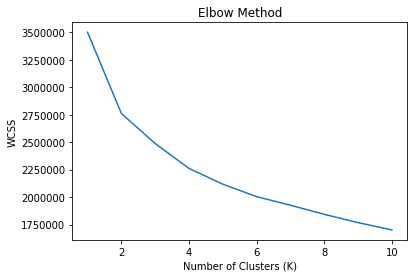

In [38]:
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [39]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

...

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

The elbow curve shows a sharp reduction in WCSS until K = 5 and only marginal improvements afterward, indicating that 5 clusters optimally balance cluster compactness and model simplicity for customer segmentation.

In [43]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters, sample_size=10000, random_state=42)
print("Silhouette Score:", score)

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float


Silhouette Score: 0.15706315035714974


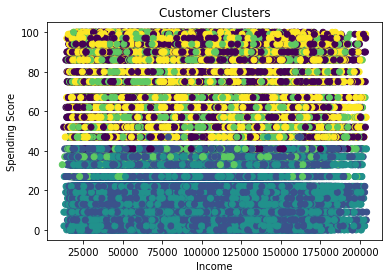

In [44]:
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=clusters)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Clusters")
plt.show()

In [45]:
df.groupby('Cluster').mean()

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore,Male
Cluster,,,,,,,,,,,,,
0,43.947683,84957.464609,16.254307,30.551368,2.173028,30.685934,0.560098,3.153986,2.353013,3.225458,0.611211,69.430834,0.000000
1,43.930359,85034.489468,5.908686,30.624958,2.157839,54.568490,0.435179,3.153378,2.349509,3.215407,0.415919,20.150551,1.000000
2,43.848800,85229.184710,5.725147,30.634686,2.165105,56.417448,0.432258,3.153310,2.354611,3.218031,0.389512,19.385210,0.000000
3,44.063015,84942.223834,15.144309,30.553476,2.166864,143.717833,0.549168,3.153661,2.354572,3.225053,0.000000,63.653855,0.501319
4,43.951734,85159.703489,16.485008,30.588642,2.155990,31.637623,0.560467,3.158425,2.347551,3.216872,0.607733,70.689033,1.000000


KMeans clustering divided customers into five segments based on their purchase frequency and recency, identifying loyal high spenders, low-engagement users, inactive customers, churn-risk customers, and premium top performers.